# Обработка подаваемого изображения

In [189]:
import cv2
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import copy

# Вспомогательные функции

In [190]:
# отображение чертежа
def visual(img, name='image'):
    plt.subplot(1, 1, 1) 
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(name) 

## Cчитыватель изображения

In [191]:
test_image_path = r'D:\A_projects\drawings_scanner\notebooks\drawing_photo_2.jpg'

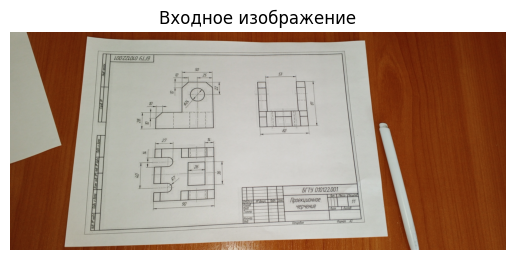

In [192]:
image = cv2.imread(test_image_path)

if (type(image) != np.ndarray) or (type(image) != np.ndarray):
    print('Не корректный путь к файлу')

else:
    visual(img=image, name='Входное изображение')

## Обрабатываем изображение

In [193]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # делаем серым

ret, contrast_image = cv2.threshold(gray_image, 170, 255, cv2.THRESH_BINARY)

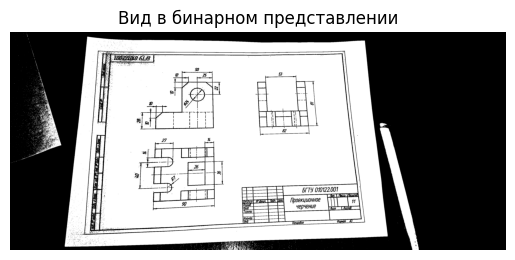

In [194]:
visual(contrast_image, 'Вид в бинарном представлении')

Количество контуров: 9206


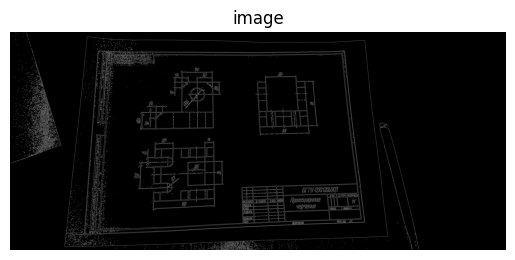

In [195]:
edged = cv2.Canny(contrast_image, 20, 255)
contours, hierarchy = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

print("Количество контуров: " + str(len(contours))) 
visual(contrast_image)
visual(edged)

In [196]:
# Получение глваного контура
len_edged = []
for i in edged:
    len_edged.append(len(i))
    
id_main_edged = len_edged.index(max(len_edged))
id_main_edged
head_edged = edged[id_main_edged]

In [197]:
# Получение глваного контура
print(len(contours))
len_contours = []
for i in contours:
    len_contours.append(len(i))
    
id_main_contours = len_contours.index(max(len_contours))
id_main_contours
head_contours = contours[id_main_contours]

9206


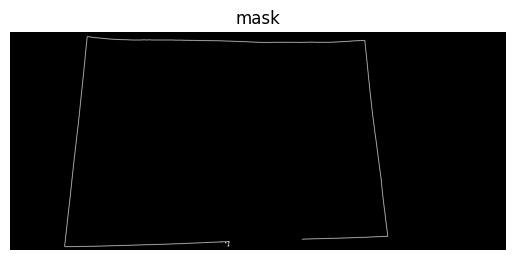

In [198]:
img = image

contours = contours
idx = id_main_contours 
mask = np.zeros_like(img) 
cv2.drawContours(mask, head_contours, -1, (255, 255, 255), 3) 
visual(mask, 'mask') 


In [199]:
img.shape

(1728, 3936, 3)

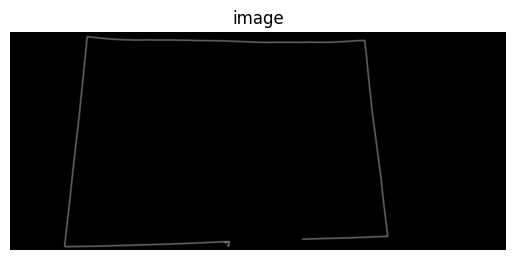

In [200]:
img = copy.deepcopy(mask)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.blur(gray, (13,13))  
visual(blur)
corners = cv2.goodFeaturesToTrack(blur, 6, 0.01, 1) #27, 0.01, 10)

for i in corners: 
    x, y = i.ravel() 
    d = (int(x),int(y))
    cv2.circle(img=img, center=d, radius=15, color=(0,255,0), thickness=-1) 

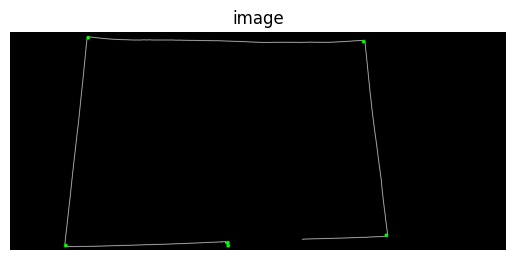

In [201]:
visual(img)

In [202]:
# Сортируем точки(границы)
print(corners)
print('___')

left_up = 0
left_down = 0
right_up = 0
right_down = 0

[[[2987. 1611.]]

 [[ 442. 1692.]]

 [[1727. 1670.]]

 [[ 620.   45.]]

 [[2807.   76.]]

 [[1731. 1693.]]]
___


In [ ]:
np.argmin(corners)
np.max(corners, axis=1)

array([[2987., 1611.],
       [ 442., 1692.],
       [1727., 1670.],
       [ 620.,   45.],
       [2807.,   76.],
       [1731., 1693.]], dtype=float32)

In [204]:
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    rect[0] = pts[np.argmin(s)]      # top-left
    rect[2] = pts[np.argmax(s)]      # bottom-right
    rect[1] = pts[np.argmin(diff)]   # top-right
    rect[3] = pts[np.argmax(diff)]   # bottom-left

    return rect

doc_cnt = corners[:4].reshape(4, 2)
print(doc_cnt)
ordered = order_points(doc_cnt)
print(ordered)


[[2987. 1611.]
 [ 442. 1692.]
 [1727. 1670.]
 [ 620.   45.]]
[[ 620.   45.]
 [2987. 1611.]
 [2987. 1611.]
 [ 442. 1692.]]


In [205]:
'''(w, h) = (595, 842)  # Примерный размер листа A4 в пикселях @72 DPI
dst = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype="float32")

M = cv2.getPerspectiveTransform(ordered, dst)
warped = cv2.warpPerspective(img, M, (w, h))
'''

'(w, h) = (595, 842)  # Примерный размер листа A4 в пикселях @72 DPI\ndst = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype="float32")\n\nM = cv2.getPerspectiveTransform(ordered, dst)\nwarped = cv2.warpPerspective(img, M, (w, h))\n'

In [206]:
'''warped_gray = cv2.cvtColor(warped, cv2.COLOR_RGB2GRAY)
scanned = cv2.adaptiveThreshold(warped_gray, 255, 
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                 cv2.THRESH_BINARY, 11, 2)
'''

'warped_gray = cv2.cvtColor(warped, cv2.COLOR_RGB2GRAY)\nscanned = cv2.adaptiveThreshold(warped_gray, 255, \n                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \n                                 cv2.THRESH_BINARY, 11, 2)\n'

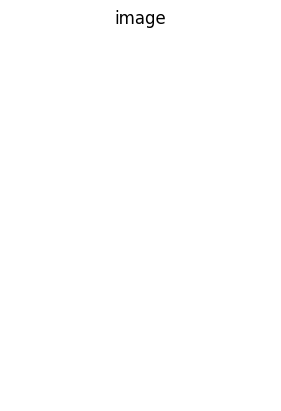

In [207]:
visual(scanned)